**Description Of the features of the dataset:**

Y – Latitude coordinate of the observation station.
X – Longitude coordinate of the observation station.
data_payload_id – Unique identifier for the data record.
instance_datetime – Timestamp when the data was recorded.
url – URL reference to the data source.
agency – Organization responsible for the data.
platform_type – Type of platform (e.g., station, balloon, etc.).
platform_id – Numeric ID for the platform.
platform_name – Name of the observation platform or station.
gaw_id – Global Atmosphere Watch ID of the platform.
instrument_name – Name of the instrument used for measurement.
instrument_model – Model of the instrument.
instrument_number – Instrument's identification number.
monthly_date – Date associated with monthly aggregated data.
monthly_columno3 – Monthly average ozone column value.
monthly_stddevo3 – Standard deviation of the monthly ozone values.
monthly_npts – Number of observations used in monthly average.
daily_date – Date of the daily observation.
daily_wlcode – Wavelength code used during observation.
daily_obscode – Observation code (e.g., method or technique).
daily_columno3 – Daily ozone column measurement (Dobson Units).
daily_stddevo3 – Standard deviation of the daily ozone value.
daily_utc_begin – UTC time when observation began.
daily_utc_end – UTC time when observation ended.
daily_utc_mean – Mean UTC time of observation.
daily_nobs – Number of observations for that day.
daily_mmu – Measurement uncertainty for daily ozone.
daily_columnso2 – Daily SO₂ (sulfur dioxide) column measurement.
latest_observation – Flag indicating if this is the most recent data (0 or 1).
country – Country of the observation station.
scientific_authority – Name of the responsible scientist or authority.
version – Version number of the data record.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.api import ExponentialSmoothing, SimpleExpSmoothing, Holt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler


In [3]:
df=pd.read_csv('New Dataset/result _2.csv')
df.head()


NameError: name 'pd' is not defined

In [20]:
df=df.drop(['Y', 'X', 'data_payload_id', 'instance_datetime', 'url', 'agency',
       'platform_type', 'platform_id', 'platform_name', 'gaw_id',
       'instrument_name', 'instrument_model', 'instrument_number',
       'monthly_date', 'monthly_stddevo3', 'monthly_npts','daily_stddevo3',
        'daily_wlcode', 'daily_obscode', 'monthly_columno3',
        'daily_utc_begin', 'daily_utc_end', 'daily_utc_mean',
       'daily_nobs', 'daily_mmu', 'daily_columnso2', 'latest_observation',
       'country', 'scientific_authority', 'version'], axis = 1)
df.head()

,daily_date,daily_columno3
0,2023-12-30,391.7
1,2023-12-10,345.1
2,2023-12-17,336.0
3,2023-12-20,341.5
4,2023-12-01,378.6


In [21]:
# df['daily_date'] = pd.to_datetime(df['daily_date'], format='%d-%m-%y')

# 2. Sort the dataframe by the full date (oldest to latest)
# scaler = MinMaxScaler()
# df['daily_columno3'] = scaler.fit_transform(df[['daily_columno3']])
df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)

# Rolling average feature (7-day)
df['rolling_avg'] = df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
df['rolling_std'] = df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
df['ewm_avg'] = df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
df['ewm_std'] = df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 121):
  df[f'lag{i}'] = df['daily_columno3'].shift(i)

df.dropna(inplace=True)
print(df.shape)
df.head()


(192308, 126)


/tmp/ipykernel_14293/430436906.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag{i}'] = df['daily_columno3'].shift(i)
/tmp/ipykernel_14293/430436906.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag{i}'] = df['daily_columno3'].shift(i)
/tmp/ipykernel_14293/430436906.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmen

,daily_date,daily_columno3,rolling_avg,rolling_std,ewm_avg,ewm_std,lag1,lag2,lag3,lag4,...,lag111,lag112,lag113,lag114,lag115,lag116,lag117,lag118,lag119,lag120
120,1957-08-08,302.0,310.04,25.114370,309.535828,21.963537,292.3,327.4,319.6,296.2,...,322.5,308.9,322.5,331.3,313.7,322.5,321.5,337.1,365.4,336.1
121,1957-08-08,296.2,311.69,23.832259,308.165678,20.101617,302.0,292.3,327.4,319.6,...,322.5,322.5,308.9,322.5,331.3,313.7,322.5,321.5,337.1,365.4
122,1957-08-08,333.2,305.16,16.479900,305.990100,18.822128,296.2,302.0,292.3,327.4,...,312.8,322.5,322.5,308.9,322.5,331.3,313.7,322.5,321.5,337.1
123,1957-08-09,267.9,310.42,16.161188,310.937355,20.303595,333.2,296.2,302.0,292.3,...,345.9,312.8,322.5,322.5,308.9,322.5,331.3,313.7,322.5,321.5
124,1957-08-09,302.0,306.42,21.061434,303.112381,25.366021,267.9,333.2,296.2,302.0,...,322.5,345.9,312.8,322.5,322.5,308.9,322.5,331.3,313.7,322.5


In [22]:
lag_features = [f'lag{i}' for i in range(1, 121)]
lag_features.append('rolling_avg')
lag_features.append('rolling_std')
lag_features.append('ewm_avg')
lag_features.append('ewm_std')
X= df[lag_features]
y = df['daily_columno3']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

**Trying Stacking Regressor**

Epoch 0, Loss: 0.7802
Epoch 50, Loss: 0.4641
Epoch 100, Loss: 0.4314
Epoch 150, Loss: 0.4233

🔍 Final Evaluation (Stacked PyTorch Model):
RMSE: 34.096
R2  : 54.32%


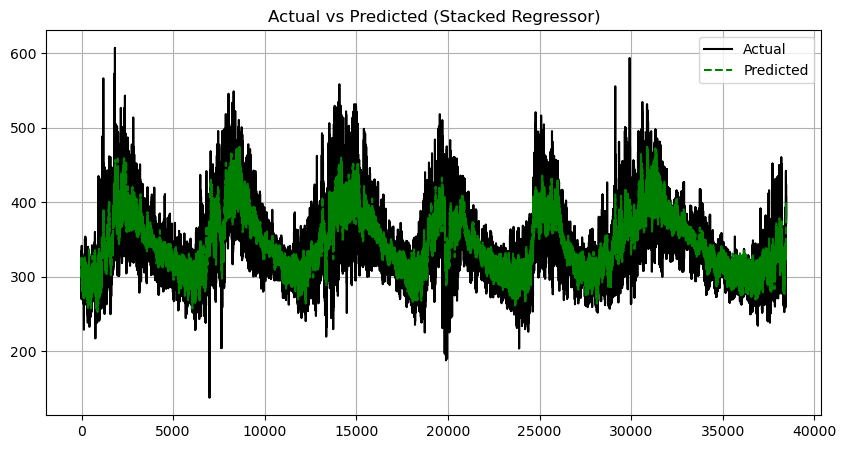


Baseline (Average of Base Models): RMSE=33.264, R2=56.53%


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------------- Data Preparation ----------------
# Feature normalization for neural networks
scaler_X = StandardScaler()
scaler_y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)
y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
y_test_scaled = scaler_y.transform(y_test.values.reshape(-1, 1))

X_train_torch = torch.tensor(X_train_scaled, dtype=torch.float32).to(device)
X_test_torch = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)
y_train_torch = torch.tensor(y_train_scaled, dtype=torch.float32).to(device)
y_test_torch = torch.tensor(y_test_scaled, dtype=torch.float32).to(device)

# ---------------- Base Models ----------------

class DeepNN(nn.Module):
    def __init__(self, input_dim):
        super(DeepNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

class ShallowNN(nn.Module):
    def __init__(self, input_dim):
        super(ShallowNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

class WideNN(nn.Module):
    def __init__(self, input_dim):
        super(WideNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
base_models = [
    DeepNN(input_dim).to(device),
    ShallowNN(input_dim).to(device),
    WideNN(input_dim).to(device)
]

# ---------------- Training Function with EarlyStopping ----------------
def train_model(model, X, y, epochs=300, lr=0.001, patience=20, verbose=False):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=10, factor=0.5)
    best_loss = np.inf
    patience_counter = 0
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        scheduler.step(loss)
        if loss.item() < best_loss:
            best_loss = loss.item()
            patience_counter = 0
        else:
            patience_counter += 1
        if verbose and epoch % 50 == 0:
            print(f"Epoch {epoch}, Loss: {loss.item():.4f}")
        if patience_counter > patience:
            break
    return model

# Train all base models
for model in base_models:
    train_model(model, X_train_torch, y_train_torch, epochs=300, lr=0.001, patience=20, verbose=False)

# ---------------- Meta-Model ----------------

with torch.no_grad():
    base_train_preds = torch.cat([model(X_train_torch) for model in base_models], dim=1)
    base_test_preds = torch.cat([model(X_test_torch) for model in base_models], dim=1)

class DeepMetaRegressor(nn.Module):
    def __init__(self, input_dim):
        super(DeepMetaRegressor, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 1)
        )
    def forward(self, x):
        return self.net(x)

meta_model = DeepMetaRegressor(len(base_models)).to(device)
train_model(meta_model, base_train_preds, y_train_torch, epochs=200, lr=0.001, patience=15, verbose=True)

# ---------------- Evaluation ----------------

with torch.no_grad():
    final_preds_scaled = meta_model(base_test_preds).cpu().numpy()
    y_test_np_scaled = y_test_torch.cpu().numpy()
    # Inverse transform to original scale
    final_preds = scaler_y.inverse_transform(final_preds_scaled)
    y_test_np = scaler_y.inverse_transform(y_test_np_scaled)

mse = mean_squared_error(y_test_np, final_preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_np, final_preds)

print(f"\n🔍 Final Evaluation (Stacked PyTorch Model):")
print(f"RMSE: {rmse:.3f}")
print(f"R2  : {r2 * 100:.2f}%")

# ---------------- Plotting ----------------

plt.figure(figsize=(10, 5))
plt.plot(y_test_np, label='Actual', color='black')
plt.plot(final_preds, label='Predicted', linestyle='--', color='green')
plt.title('Actual vs Predicted (Stacked Regressor)')
plt.legend()
plt.grid(True)
plt.show()

# ---------------- Baseline: Simple Average of Base Models ----------------
with torch.no_grad():
    avg_preds_scaled = base_test_preds.mean(dim=1, keepdim=True).cpu().numpy()
    avg_preds = scaler_y.inverse_transform(avg_preds_scaled)
mse_avg = mean_squared_error(y_test_np, avg_preds)
rmse_avg = np.sqrt(mse_avg)
r2_avg = r2_score(y_test_np, avg_preds)
print(f"\nBaseline (Average of Base Models): RMSE={rmse_avg:.3f}, R2={r2_avg*100:.2f}%")

**GPU Based Models**

In [5]:
df=pd.read_csv('New Dataset/result _2.csv')
df.head()


/tmp/ipykernel_728/334508303.py:1: DtypeWarning: Columns (19,30) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv('New Dataset/result _2.csv')


,Y,X,data_payload_id,instance_datetime,url,agency,platform_type,platform_id,platform_name,gaw_id,...,daily_utc_begin,daily_utc_end,daily_utc_mean,daily_nobs,daily_mmu,daily_columnso2,latest_observation,country,scientific_authority,version
0,43.781,-79.468,2260788,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,15.6,19.3,17.4,22.0,2.7,-6.7,0,CAN,Vitali Fioletov,4.15
1,43.781,-79.468,2260768,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,15.1,19.6,17.2,21.0,2.8,-4.9,0,CAN,Vitali Fioletov,4.15
2,43.781,-79.468,2260775,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,15.0,18.9,17.7,15.0,2.7,-3.3,0,CAN,Vitali Fioletov,4.15
3,43.781,-79.468,2260778,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,65,Toronto,TOT,...,17.5,19.5,18.5,11.0,2.9,0.9,0,CAN,Vitali Fioletov,4.15
4,58.739,-94.074,2260790,2023/12/01 00:00:00+00,https://woudc.org/archive/Archive-NewFormat/To...,MSC,STN,77,Churchill,CHL,...,13.9,13.9,13.9,1.0,1.7,-3.5,0,CAN,Vitali Fioletov,4.16


In [6]:
df=df.drop(['Y', 'X', 'data_payload_id', 'instance_datetime', 'url', 'agency',
       'platform_type', 'platform_id', 'platform_name', 'gaw_id',
       'instrument_name', 'instrument_model', 'instrument_number',
       'monthly_date', 'monthly_stddevo3', 'monthly_npts','daily_stddevo3',
        'daily_wlcode', 'daily_obscode', 'monthly_columno3',
        'daily_utc_begin', 'daily_utc_end', 'daily_utc_mean',
       'daily_nobs', 'daily_mmu', 'daily_columnso2', 'latest_observation',
       'country', 'scientific_authority', 'version'], axis = 1)
df.head()

,daily_date,daily_columno3
0,2023-12-30,391.7
1,2023-12-10,345.1
2,2023-12-17,336.0
3,2023-12-20,341.5
4,2023-12-01,378.6


In [7]:
# df['daily_date'] = pd.to_datetime(df['daily_date'], format='%d-%m-%y')

# 2. Sort the dataframe by the full date (oldest to latest)
scaler = MinMaxScaler()
df['daily_columno3'] = scaler.fit_transform(df[['daily_columno3']])
df = df.sort_values('daily_date', ascending=True).reset_index(drop=True)

# Rolling average feature (7-day)
df['rolling_avg'] = df['daily_columno3'].shift(1).rolling(window=10).mean().bfill()
df['rolling_std'] = df['daily_columno3'].shift(1).rolling(window=10).std().bfill()
df['ewm_avg'] = df['daily_columno3'].shift(1).ewm(span=10).mean().bfill()
df['ewm_std'] = df['daily_columno3'].shift(1).ewm(span=10).std().bfill()
for i in range(1, 151):
  df[f'lag{i}'] = df['daily_columno3'].shift(i)

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(df.shape)
df.head()

/tmp/ipykernel_728/1349193536.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag{i}'] = df['daily_columno3'].shift(i)
/tmp/ipykernel_728/1349193536.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f'lag{i}'] = df['daily_columno3'].shift(i)
/tmp/ipykernel_728/1349193536.py:14: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented

(192278, 156)


,daily_date,daily_columno3,rolling_avg,rolling_std,ewm_avg,ewm_std,lag1,lag2,lag3,lag4,...,lag141,lag142,lag143,lag144,lag145,lag146,lag147,lag148,lag149,lag150
150,1957-08-16,0.431874,0.348752,0.067825,0.363544,0.062168,0.332242,0.439853,0.423895,0.407938,...,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023,0.407938,0.465835,0.405892
151,1957-08-17,0.378069,0.360311,0.071430,0.375967,0.062721,0.431874,0.332242,0.439853,0.423895,...,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023,0.407938,0.465835
152,1957-08-17,0.310352,0.371870,0.062653,0.376349,0.056739,0.378069,0.431874,0.332242,0.439853,...,0.358224,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023,0.407938
153,1957-08-17,0.425941,0.376268,0.055567,0.364350,0.057913,0.310352,0.378069,0.431874,0.332242,...,0.425941,0.358224,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023
154,1957-08-18,0.258388,0.377066,0.056285,0.375548,0.058062,0.425941,0.310352,0.378069,0.431874,...,0.378069,0.425941,0.358224,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069


In [8]:

lag_features = [f'lag{i}' for i in range(1, 151)]
lag_features.append('rolling_avg')
lag_features.append('rolling_std')
lag_features.append('ewm_avg')
lag_features.append('ewm_std')
X= df[lag_features]
y = df['daily_columno3']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

In [54]:
df.head()

,daily_date,daily_columno3,rolling_avg,rolling_std,ewm_avg,ewm_std,lag1,lag2,lag3,lag4,...,lag141,lag142,lag143,lag144,lag145,lag146,lag147,lag148,lag149,lag150
150,1957-08-16,0.431874,0.348752,0.067825,0.363544,0.062168,0.332242,0.439853,0.423895,0.407938,...,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023,0.407938,0.465835,0.405892
151,1957-08-17,0.378069,0.360311,0.071430,0.375967,0.062721,0.431874,0.332242,0.439853,0.423895,...,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023,0.407938,0.465835
152,1957-08-17,0.310352,0.371870,0.062653,0.376349,0.056739,0.378069,0.431874,0.332242,0.439853,...,0.358224,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023,0.407938
153,1957-08-17,0.425941,0.376268,0.055567,0.364350,0.057913,0.310352,0.378069,0.431874,0.332242,...,0.425941,0.358224,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069,0.376023
154,1957-08-18,0.258388,0.377066,0.056285,0.375548,0.058062,0.425941,0.310352,0.378069,0.431874,...,0.378069,0.425941,0.358224,0.378069,0.378069,0.350245,0.378069,0.396072,0.360065,0.378069


Using device: cuda
Training Simple MLP...
Simple MLP - RMSE: 0.0713, R2: 52.33 %
Training Deep MLP...
Deep MLP - RMSE: 0.0701, R2: 53.89 %
Training MLP with Dropout...
MLP with Dropout - RMSE: 0.0767, R2: 44.83 %
Training MLP with BatchNorm...
MLP with BatchNorm - RMSE: 0.0720, R2: 51.30 %
Training 1D CNN...
1D CNN - RMSE: 0.0679, R2: 56.73 %
Training CNN + MLP...
CNN + MLP - RMSE: 0.0693, R2: 54.89 %
Training LSTM...
LSTM - RMSE: 0.0715, R2: 51.98 %
Training GRU...
GRU - RMSE: 0.0698, R2: 54.29 %

Best model: 1D CNN with R2 = 56.73 %


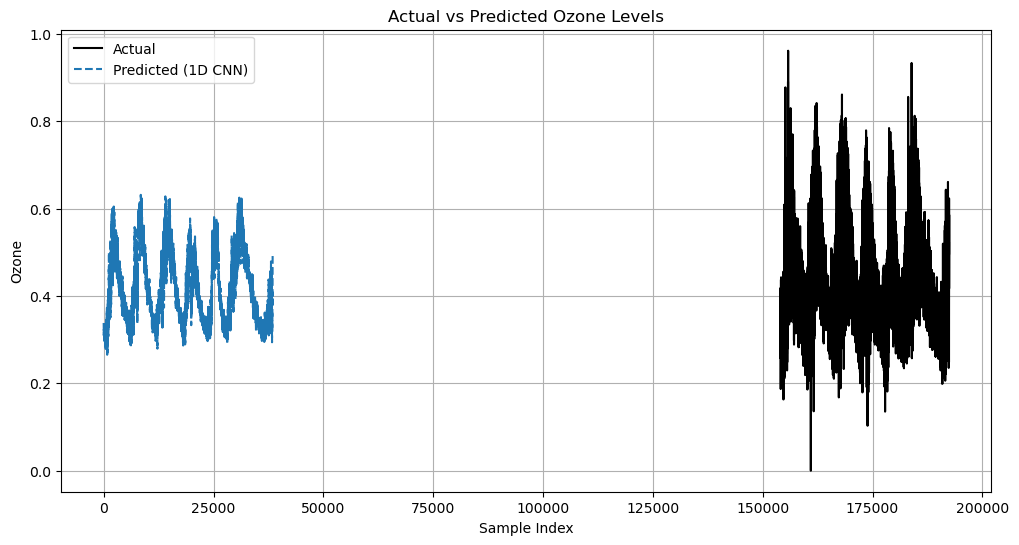

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


# Convert pandas DataFrame/Series to numpy, then to torch tensors
X_train_t = torch.tensor(X_train.values, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test.values, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1).to(device)
y_test_t = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1).to(device)

input_dim = X_train.shape[1]  # Number of features

# ----------- Models -----------

# 1. Simple MLP
class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# 2. Deeper MLP
class DeepMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# 3. MLP with Dropout
class MLPDropout(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# 4. MLP with BatchNorm
class MLPBatchNorm(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.net(x)

# 5. 1D CNN (for time series with multiple features)
class CNN1D(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)
        self.fc = nn.Linear(32 * input_dim, 1)
        self.relu = nn.ReLU()

    def forward(self, x):
        # x shape: (batch_size, features)
        x = x.unsqueeze(1)  # shape (batch_size, 1, features)
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# 6. CNN + MLP Hybrid
class CNN_MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(1, 16, 3, padding=1),
            nn.ReLU(),
            nn.Conv1d(16, 32, 3, padding=1),
            nn.ReLU()
        )
        self.mlp = nn.Sequential(
            nn.Linear(32 * input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
    def forward(self, x):
        x = x.unsqueeze(1)
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.mlp(x)

# 7. LSTM Regressor
class LSTMRegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # input expected: (batch, seq_len, features)
        x = x.unsqueeze(1)  # Add seq_len dimension = 1, shape (batch, 1, features)
        _, (hn, _) = self.lstm(x)
        out = self.fc(hn[-1])
        return out

# 8. GRU Regressor
class GRURegressor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = x.unsqueeze(1)  # shape (batch, seq_len=1, features)
        _, hn = self.gru(x)
        out = self.fc(hn[-1])
        return out

# ----------- Training function -----------
def train_model(model, X, y, epochs=100, lr=0.001):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
    return model

# ----------- Evaluate model -----------
def evaluate_model(model, X, y_true):
    model.eval()
    with torch.no_grad():
        preds = model(X).cpu().numpy()
        y_true = y_true.cpu().numpy()
        mse = mean_squared_error(y_true, preds)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(y_true, preds)
        r2 = r2_score(y_true, preds)
    return preds, mse, rmse, mae, r2

# ----------- Run models -----------
models = {
    'Simple MLP': SimpleMLP(input_dim),
    'Deep MLP': DeepMLP(input_dim),
    'MLP with Dropout': MLPDropout(input_dim),
    'MLP with BatchNorm': MLPBatchNorm(input_dim),
    '1D CNN': CNN1D(input_dim),
    'CNN + MLP': CNN_MLP(input_dim),
    'LSTM': LSTMRegressor(input_dim),
    'GRU': GRURegressor(input_dim),
}

results = {}

for name, model in models.items():
    print(f"Training {name}...")
    train_model(model, X_train_t, y_train_t, epochs=150, lr=0.001)
    preds, mse, rmse, mae, r2 = evaluate_model(model, X_test_t, y_test_t)
    results[name] = {'model': model, 'preds': preds, 'mse': mse, 'rmse': rmse, 'mae': mae, 'r2': r2}
    print(f"{name} - RMSE: {rmse:.4f}, R2: {r2*100:.2f} %")

# ----------- Plot best model results -----------
best_model_name = max(results, key=lambda k: results[k]['r2'])
print(f"\nBest model: {best_model_name} with R2 = {results[best_model_name]['r2']*100:.2f} %")

plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual', color='black')
plt.plot(results[best_model_name]['preds'], label=f'Predicted ({best_model_name})', linestyle='--')
plt.title('Actual vs Predicted Ozone Levels')
plt.xlabel('Sample Index')
plt.ylabel('Ozone')
plt.legend()
plt.grid(True)
plt.show()


**Hyper Parameter Tuning**

**Optuna**

In [ ]:
import optuna
from optuna.samplers import TPESampler, NSGAIISampler, RandomSampler
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split

# Assume X_train_t, y_train_t, X_test_t, y_test_t, X_train, y_train are already defined
X_tr, X_val, y_tr, y_val = train_test_split(X_train_t, y_train_t, test_size=0.2, shuffle=False)

input_dim = X_train_t.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- Model Factory for Optuna ---------- #
def create_model(trial, input_dim, model_type):
    if model_type == 'SimpleMLP':
        hidden = trial.suggest_int("hidden", 32, 128)
        return nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    elif model_type == 'DeepMLP':
        h1 = trial.suggest_int("h1", 64, 256)
        h2 = trial.suggest_int("h2", 32, 128)
        return nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Linear(h2, 1)
        )

    elif model_type == 'MLPDropout':
        h1 = trial.suggest_int("h1", 64, 256)
        h2 = trial.suggest_int("h2", 32, 128)
        dropout = trial.suggest_float("dropout", 0.1, 0.5)
        return nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h1, h2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(h2, 1)
        )

    elif model_type == 'CNN1D':
        out_channels = trial.suggest_int("out_channels", 16, 64)
        kernel_size = trial.suggest_int("kernel_size", 2, 5)
        class CNN1D(nn.Module):
            def __init__(self):
                super().__init__()
                self.conv = nn.Sequential(
                    nn.Conv1d(1, out_channels, kernel_size=kernel_size, padding=1),
                    nn.ReLU(),
                    nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=1),
                    nn.ReLU()
                )
                self.gap = nn.AdaptiveAvgPool1d(1)
                self.fc = nn.Linear(out_channels, 1)

            def forward(self, x):
                x = x.unsqueeze(1)
                x = self.conv(x)
                x = self.gap(x).squeeze(-1)
                return self.fc(x)
        return CNN1D()

    elif model_type == 'LSTM':
        hidden = trial.suggest_int("hidden_dim", 32, 128)
        layers = trial.suggest_int("num_layers", 1, 3)
        class LSTMRegressor(nn.Module):
            def __init__(self):
                super().__init__()
                self.lstm = nn.LSTM(input_dim, hidden, layers, batch_first=True)
                self.fc = nn.Linear(hidden, 1)

            def forward(self, x):
                x = x.unsqueeze(1)
                _, (hn, _) = self.lstm(x)
                return self.fc(hn[-1])
        return LSTMRegressor()

    elif model_type == 'GRU':
        hidden = trial.suggest_int("hidden_dim", 32, 128)
        layers = trial.suggest_int("num_layers", 1, 3)
        class GRURegressor(nn.Module):
            def __init__(self):
                super().__init__()
                self.gru = nn.GRU(input_dim, hidden, layers, batch_first=True)
                self.fc = nn.Linear(hidden, 1)

            def forward(self, x):
                x = x.unsqueeze(1)
                _, hn = self.gru(x)
                return self.fc(hn[-1])
        return GRURegressor()

    else:
        raise ValueError(f"Unknown model type: {model_type}")

# ---------- Training and Evaluation ---------- #
def train_model(model, X_train, y_train, epochs=300, lr=1e-3):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    for epoch in range(epochs):
        optimizer.zero_grad()
        out = model(X_train)
        loss = criterion(out, y_train)
        loss.backward()
        optimizer.step()

def evaluate_model(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        preds = model(X_test).cpu().numpy()
        true = y_test.cpu().numpy()
        mse = mean_squared_error(true, preds)
        rmse = np.sqrt(mse)
        mae = mean_absolute_error(true, preds)
        r2 = r2_score(true, preds)
    return preds, mse, rmse, mae, r2

# ---------- Objective Function ---------- #
def objective(trial):
    model_type = trial.suggest_categorical("model_type", ["SimpleMLP", "DeepMLP", "MLPDropout", "CNN1D", "LSTM", "GRU"])
    model = create_model(trial, input_dim=X_tr.shape[1], model_type=model_type).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=trial.suggest_float("lr", 1e-4, 1e-2, log=True))
    model.train()
    for epoch in range(100):
        optimizer.zero_grad()
        out = model(X_tr)
        loss = criterion(out, y_tr)
        loss.backward()
        optimizer.step()
    model.eval()
    with torch.no_grad():
        preds = model(X_val).cpu().numpy()
        true = y_val.cpu().numpy()
        r2 = r2_score(true, preds)
    return r2

# ---------- Run Multiple Studies with Different Samplers ---------- #
samplers = {
    "TPE": TPESampler(seed=42),
    "NSGAII": NSGAIISampler(seed=42),
    "Random": RandomSampler(seed=42),
}

best_trials = {}
for name, sampler in samplers.items():
    print(f"Running {name} search...")
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=50)
    best_trials[name] = study.best_trial
    print(f"Best {name} Trial:\n{study.best_trial}\n")

# ---------- Evaluate All Best Models on Test Set ---------- #
all_results = {}
for name, trial in best_trials.items():
    model_type = trial.params['model_type']
    model = create_model(trial, input_dim, model_type).to(device)
    train_model(model, X_train_t, y_train_t, epochs=300, lr=trial.params['lr'])
    preds, mse, rmse, mae, r2 = evaluate_model(model, X_test_t, y_test_t)
    all_results[name] = {
        "model_type": model_type,
        "r2": r2,
        "rmse": rmse,
        "mae": mae,
        "mse": mse,
    }

# ---------- Print Evaluation Results ---------- #
print("\n--- Evaluation of Best Models from Each Search ---")
for name, result in all_results.items():
    print(f"{name} Search:")
    print(f"  Model      : {result['model_type']}")
    print(f"  R²         : {result['r2']:.4f}")
    print(f"  RMSE       : {result['rmse']:.4f}")
    print(f"  MAE        : {result['mae']:.4f}")
    print(f"  MSE        : {result['mse']:.4f}\n")


[I 2025-06-06 12:15:30,403] A new study created in memory with name: no-name-1b6d5964-413a-4861-8c49-601badbe465d


Running TPE search...


[I 2025-06-06 12:15:30,642] Trial 0 finished with value: 0.5318624973297119 and parameters: {'model_type': 'DeepMLP', 'h1': 75, 'h2': 116, 'lr': 0.0015930522616241021}. Best is trial 0 with value: 0.5318624973297119.
[I 2025-06-06 12:15:30,891] Trial 1 finished with value: 0.37094056606292725 and parameters: {'model_type': 'MLPDropout', 'h1': 99, 'h2': 61, 'dropout': 0.3099025726528951, 'lr': 0.0007309539835912913}. Best is trial 0 with value: 0.5318624973297119.
[I 2025-06-06 12:15:31,228] Trial 2 finished with value: 0.5362516641616821 and parameters: {'model_type': 'DeepMLP', 'h1': 215, 'h2': 51, 'lr': 0.0010677482709481358}. Best is trial 2 with value: 0.5362516641616821.
[I 2025-06-06 12:16:22,798] Trial 3 finished with value: 0.5137620568275452 and parameters: {'model_type': 'GRU', 'hidden_dim': 125, 'num_layers': 3, 'lr': 0.0004066563313514797}. Best is trial 2 with value: 0.5362516641616821.
[I 2025-06-06 12:16:23,130] Trial 4 finished with value: 0.5357823371887207 and paramet

Best TPE Trial:
FrozenTrial(number=46, state=TrialState.COMPLETE, values=[0.5718417167663574], datetime_start=datetime.datetime(2025, 6, 6, 12, 37, 51, 425105), datetime_complete=datetime.datetime(2025, 6, 6, 12, 37, 55, 926431), params={'model_type': 'GRU', 'hidden_dim': 66, 'num_layers': 2, 'lr': 0.004556577064715768}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'model_type': CategoricalDistribution(choices=('SimpleMLP', 'DeepMLP', 'MLPDropout', 'CNN1D', 'LSTM', 'GRU')), 'hidden_dim': IntDistribution(high=128, log=False, low=32, step=1), 'num_layers': IntDistribution(high=3, log=False, low=1, step=1), 'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None)}, trial_id=46, value=None)

Running NSGAII search...


[I 2025-06-06 12:38:09,715] Trial 0 finished with value: 0.5417439937591553 and parameters: {'model_type': 'DeepMLP', 'h1': 75, 'h2': 116, 'lr': 0.0015930522616241021}. Best is trial 0 with value: 0.5417439937591553.
[I 2025-06-06 12:38:09,957] Trial 1 finished with value: 0.46888428926467896 and parameters: {'model_type': 'MLPDropout', 'h1': 99, 'h2': 61, 'dropout': 0.3099025726528951, 'lr': 0.0007309539835912913}. Best is trial 0 with value: 0.5417439937591553.
[I 2025-06-06 12:38:10,285] Trial 2 finished with value: 0.5079838037490845 and parameters: {'model_type': 'DeepMLP', 'h1': 215, 'h2': 51, 'lr': 0.0010677482709481358}. Best is trial 0 with value: 0.5417439937591553.
[I 2025-06-06 12:39:02,795] Trial 3 finished with value: 0.5174723863601685 and parameters: {'model_type': 'GRU', 'hidden_dim': 125, 'num_layers': 3, 'lr': 0.0004066563313514797}. Best is trial 0 with value: 0.5417439937591553.
[I 2025-06-06 12:39:03,150] Trial 4 finished with value: 0.5293513536453247 and paramet

Best NSGAII Trial:
FrozenTrial(number=12, state=TrialState.COMPLETE, values=[0.5763011574745178], datetime_start=datetime.datetime(2025, 6, 6, 12, 48, 19, 922099), datetime_complete=datetime.datetime(2025, 6, 6, 12, 49, 5, 82169), params={'model_type': 'LSTM', 'hidden_dim': 93, 'num_layers': 3, 'lr': 0.004048966222584676}, user_attrs={}, system_attrs={'NSGAIISampler:generation': 0}, intermediate_values={}, distributions={'model_type': CategoricalDistribution(choices=('SimpleMLP', 'DeepMLP', 'MLPDropout', 'CNN1D', 'LSTM', 'GRU')), 'hidden_dim': IntDistribution(high=128, log=False, low=32, step=1), 'num_layers': IntDistribution(high=3, log=False, low=1, step=1), 'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None)}, trial_id=12, value=None)

Running Random search...


[I 2025-06-06 14:01:33,660] Trial 0 finished with value: 0.5365670323371887 and parameters: {'model_type': 'DeepMLP', 'h1': 75, 'h2': 116, 'lr': 0.0015930522616241021}. Best is trial 0 with value: 0.5365670323371887.
[I 2025-06-06 14:01:33,905] Trial 1 finished with value: 0.36718910932540894 and parameters: {'model_type': 'MLPDropout', 'h1': 99, 'h2': 61, 'dropout': 0.3099025726528951, 'lr': 0.0007309539835912913}. Best is trial 0 with value: 0.5365670323371887.
[I 2025-06-06 14:01:34,237] Trial 2 finished with value: 0.5449312925338745 and parameters: {'model_type': 'DeepMLP', 'h1': 215, 'h2': 51, 'lr': 0.0010677482709481358}. Best is trial 2 with value: 0.5449312925338745.
[I 2025-06-06 14:02:22,244] Trial 3 finished with value: 0.482715904712677 and parameters: {'model_type': 'GRU', 'hidden_dim': 125, 'num_layers': 3, 'lr': 0.0004066563313514797}. Best is trial 2 with value: 0.5449312925338745.
[I 2025-06-06 14:02:22,596] Trial 4 finished with value: 0.5442367792129517 and paramete

Best Random Trial:
FrozenTrial(number=12, state=TrialState.COMPLETE, values=[0.5719559192657471], datetime_start=datetime.datetime(2025, 6, 6, 14, 11, 40, 931076), datetime_complete=datetime.datetime(2025, 6, 6, 14, 12, 25, 816942), params={'model_type': 'LSTM', 'hidden_dim': 93, 'num_layers': 3, 'lr': 0.004048966222584676}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'model_type': CategoricalDistribution(choices=('SimpleMLP', 'DeepMLP', 'MLPDropout', 'CNN1D', 'LSTM', 'GRU')), 'hidden_dim': IntDistribution(high=128, log=False, low=32, step=1), 'num_layers': IntDistribution(high=3, log=False, low=1, step=1), 'lr': FloatDistribution(high=0.01, log=True, low=0.0001, step=None)}, trial_id=12, value=None)


--- Evaluation of Best Models from Each Search ---
TPE Search:
  Model      : GRU
  R²         : 0.5689
  RMSE       : 0.0678
  MAE        : 0.0508
  MSE        : 0.0046

NSGAII Search:
  Model      : LSTM
  R²         : 0.5697
  RMSE       : 0.0677
  MAE      

**Several Tuning Samplers(Optuna)**

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
import optuna
from optuna.samplers import TPESampler, NSGAIISampler, RandomSampler
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split, ParameterGrid

# ---------- Assume tensors are predefined ---------- #
# X_train_t, y_train_t, X_test_t, y_test_t, X_train, y_train
X_tr, X_val, y_tr, y_val = train_test_split(X_train_t, y_train_t, test_size=0.2, shuffle=False)
input_dim = X_train_t.shape[1]
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---------- Model Factory ---------- #
def create_model(trial=None, input_dim=10, model_type='SimpleMLP', param_override=None):
    p = param_override if param_override else {}

    def get(key, default):
        if p.get(key) is not None:
            return p.get(key)
        elif trial is not None:
            return trial.suggest_int(key, *default)
        else:
            # Use the first value in the default tuple as the default
            return default[0]

    if model_type == 'SimpleMLP':
        hidden = get("hidden", (32, 128))
        return nn.Sequential(nn.Linear(input_dim, hidden), nn.ReLU(), nn.Linear(hidden, 1))

    elif model_type == 'DeepMLP':
        h1 = get("h1", (64, 256))
        h2 = get("h2", (32, 128))
        return nn.Sequential(nn.Linear(input_dim, h1), nn.ReLU(), nn.Linear(h1, h2), nn.ReLU(), nn.Linear(h2, 1))

    elif model_type == 'MLPDropout':
        h1 = get("h1", (64, 256))
        h2 = get("h2", (32, 128))
        dropout = p.get("dropout") if p.get("dropout") else trial.suggest_float("dropout", 0.1, 0.5)
        return nn.Sequential(
            nn.Linear(input_dim, h1), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h1, h2), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(h2, 1)
        )

    elif model_type == 'CNN1D':
        out_channels = get("out_channels", (16, 64))
        kernel_size = get("kernel_size", (2, 5))
        class CNN1D(nn.Module):
            def __init__(self):
                super().__init__()
                self.conv = nn.Sequential(
                    nn.Conv1d(1, out_channels, kernel_size=kernel_size, padding=1),
                    nn.ReLU(),
                    nn.Conv1d(out_channels, out_channels, kernel_size=kernel_size, padding=1),
                    nn.ReLU()
                )
                self.gap = nn.AdaptiveAvgPool1d(1)
                self.fc = nn.Linear(out_channels, 1)

            def forward(self, x):
                x = x.unsqueeze(1)
                x = self.conv(x)
                x = self.gap(x).squeeze(-1)
                return self.fc(x)
        return CNN1D()

    elif model_type == 'LSTM':
        hidden = get("hidden_dim", (32, 128))
        layers = get("num_layers", (1, 3))
        class LSTMRegressor(nn.Module):
            def __init__(self):
                super().__init__()
                self.lstm = nn.LSTM(input_dim, hidden, layers, batch_first=True)
                self.fc = nn.Linear(hidden, 1)

            def forward(self, x):
                x = x.unsqueeze(1)
                _, (hn, _) = self.lstm(x)
                return self.fc(hn[-1])
        return LSTMRegressor()

    elif model_type == 'GRU':
        hidden = get("hidden_dim", (32, 128))
        layers = get("num_layers", (1, 3))
        class GRURegressor(nn.Module):
            def __init__(self):
                super().__init__()
                self.gru = nn.GRU(input_dim, hidden, layers, batch_first=True)
                self.fc = nn.Linear(hidden, 1)

            def forward(self, x):
                x = x.unsqueeze(1)
                _, hn = self.gru(x)
                return self.fc(hn[-1])
        return GRURegressor()

    else:
        raise ValueError("Unknown model")

# ---------- Training ---------- #
def train_model(model, X, y, epochs=300, lr=1e-3):
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()
    for _ in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()

# ---------- Evaluation ---------- #
def evaluate_model(model, X, y):
    model.eval()
    with torch.no_grad():
        pred = model(X).cpu().numpy()
        true = y.cpu().numpy()
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(true, pred)
    r2 = r2_score(true, pred)
    return pred, mse, rmse, mae, r2

# ---------- Optuna Objective ---------- #
def objective(trial):
    model_type = trial.suggest_categorical("model_type", ["SimpleMLP", "DeepMLP", "MLPDropout", "CNN1D", "LSTM", "GRU"])
    model = create_model(trial, input_dim, model_type).to(device)
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    train_model(model, X_tr, y_tr, epochs=100, lr=lr)
    _, _, _, _, r2 = evaluate_model(model, X_val, y_val)
    return r2

# ---------- Run All Optuna Samplers ---------- #
samplers = {
    "TPE": TPESampler(seed=42),
    "NSGAII": NSGAIISampler(seed=42),
    "Random": RandomSampler(seed=42)
}
best_trials = {}
for name, sampler in samplers.items():
    print(f"Running {name} tuning...")
    study = optuna.create_study(direction="maximize", sampler=sampler)
    study.optimize(objective, n_trials=50)
    best_trials[name] = study.best_trial

# ---------- Manual Grid Search ---------- #
grid_results = []
grid = list(ParameterGrid({
    "model_type": ["SimpleMLP", "DeepMLP"],
    "lr": [0.001, 0.005],
    "hidden": [64, 128],
}))
for params in grid:
    model = create_model(None, input_dim, params['model_type'], param_override=params).to(device)
    train_model(model, X_tr, y_tr, epochs=100, lr=params['lr'])
    _, _, _, _, r2 = evaluate_model(model, X_val, y_val)
    params['r2'] = r2
    grid_results.append(params)

best_grid = max(grid_results, key=lambda x: x['r2'])

# ---------- Evaluate All Best Models ---------- #
print("\n--- Final Evaluation on Test Set ---")
all_results = {}
for name, trial in best_trials.items():
    model = create_model(trial, input_dim, trial.params['model_type']).to(device)
    train_model(model, X_train_t, y_train_t, epochs=300, lr=trial.params['lr'])
    _, mse, rmse, mae, r2 = evaluate_model(model, X_test_t, y_test_t)
    all_results[name] = {"model": trial.params['model_type'], "r2": r2, "rmse": rmse, "mae": mae, "mse": mse}

# Grid search result
grid_model = create_model(None, input_dim, best_grid['model_type'], param_override=best_grid).to(device)
train_model(grid_model, X_train_t, y_train_t, epochs=300, lr=best_grid['lr'])
_, mse, rmse, mae, r2 = evaluate_model(grid_model, X_test_t, y_test_t)
all_results['GridSearch'] = {"model": best_grid['model_type'], "r2": r2, "rmse": rmse, "mae": mae, "mse": mse}

for name, res in all_results.items():
    print(f"{name} Results:")
    print(f"  Model: {res['model']}\n  R2: {res['r2']:.4f}  RMSE: {res['rmse']:.4f}  MAE: {res['mae']:.4f}  MSE: {res['mse']:.4f}\n")


[I 2025-06-06 20:33:15,519] A new study created in memory with name: no-name-8950a597-4e35-45d8-bf94-8f63826bf887


Running TPE tuning...


[I 2025-06-06 20:33:15,771] Trial 0 finished with value: 0.5391405820846558 and parameters: {'model_type': 'DeepMLP', 'h1': 75, 'h2': 116, 'lr': 0.0015930522616241021}. Best is trial 0 with value: 0.5391405820846558.
[I 2025-06-06 20:33:16,033] Trial 1 finished with value: 0.45733368396759033 and parameters: {'model_type': 'MLPDropout', 'h1': 99, 'h2': 61, 'dropout': 0.3099025726528951, 'lr': 0.0007309539835912913}. Best is trial 0 with value: 0.5391405820846558.
[I 2025-06-06 20:33:16,335] Trial 2 finished with value: 0.5163037180900574 and parameters: {'model_type': 'DeepMLP', 'h1': 215, 'h2': 51, 'lr': 0.0010677482709481358}. Best is trial 0 with value: 0.5391405820846558.
[I 2025-06-06 20:34:08,760] Trial 3 finished with value: 0.5199827551841736 and parameters: {'model_type': 'GRU', 'hidden_dim': 125, 'num_layers': 3, 'lr': 0.0004066563313514797}. Best is trial 0 with value: 0.5391405820846558.
[I 2025-06-06 20:34:09,111] Trial 4 finished with value: 0.5464965105056763 and paramet

Running NSGAII tuning...


[I 2025-06-06 21:11:44,876] Trial 0 finished with value: 0.5335698127746582 and parameters: {'model_type': 'DeepMLP', 'h1': 75, 'h2': 116, 'lr': 0.0015930522616241021}. Best is trial 0 with value: 0.5335698127746582.
[I 2025-06-06 21:11:45,118] Trial 1 finished with value: 0.4469414949417114 and parameters: {'model_type': 'MLPDropout', 'h1': 99, 'h2': 61, 'dropout': 0.3099025726528951, 'lr': 0.0007309539835912913}. Best is trial 0 with value: 0.5335698127746582.
[I 2025-06-06 21:11:45,412] Trial 2 finished with value: 0.5102822780609131 and parameters: {'model_type': 'DeepMLP', 'h1': 215, 'h2': 51, 'lr': 0.0010677482709481358}. Best is trial 0 with value: 0.5335698127746582.
[I 2025-06-06 21:12:33,174] Trial 3 finished with value: 0.476029634475708 and parameters: {'model_type': 'GRU', 'hidden_dim': 125, 'num_layers': 3, 'lr': 0.0004066563313514797}. Best is trial 0 with value: 0.5335698127746582.
[I 2025-06-06 21:12:33,502] Trial 4 finished with value: 0.5367611050605774 and parameter

Running Random tuning...


[I 2025-06-06 22:39:42,659] Trial 0 finished with value: 0.5388920307159424 and parameters: {'model_type': 'DeepMLP', 'h1': 75, 'h2': 116, 'lr': 0.0015930522616241021}. Best is trial 0 with value: 0.5388920307159424.
[I 2025-06-06 22:39:42,970] Trial 1 finished with value: 0.3835536241531372 and parameters: {'model_type': 'MLPDropout', 'h1': 99, 'h2': 61, 'dropout': 0.3099025726528951, 'lr': 0.0007309539835912913}. Best is trial 0 with value: 0.5388920307159424.
[I 2025-06-06 22:39:43,343] Trial 2 finished with value: 0.5237081050872803 and parameters: {'model_type': 'DeepMLP', 'h1': 215, 'h2': 51, 'lr': 0.0010677482709481358}. Best is trial 0 with value: 0.5388920307159424.
[I 2025-06-06 22:40:38,739] Trial 3 finished with value: 0.5051476359367371 and parameters: {'model_type': 'GRU', 'hidden_dim': 125, 'num_layers': 3, 'lr': 0.0004066563313514797}. Best is trial 0 with value: 0.5388920307159424.
[I 2025-06-06 22:40:39,125] Trial 4 finished with value: 0.5503214001655579 and paramete


--- Final Evaluation on Test Set ---
TPE Results:
  Model: DeepMLP
  R2: 0.5691  RMSE: 0.0678  MAE: 0.0509  MSE: 0.0046

NSGAII Results:
  Model: LSTM
  R2: 0.5698  RMSE: 0.0677  MAE: 0.0507  MSE: 0.0046

Random Results:
  Model: LSTM
  R2: 0.5699  RMSE: 0.0677  MAE: 0.0507  MSE: 0.0046

GridSearch Results:
  Model: SimpleMLP
  R2: 0.5446  RMSE: 0.0697  MAE: 0.0520  MSE: 0.0049



In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, r2_score
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split

# ---- TorchRegressor ----
class TorchRegressor(BaseEstimator, RegressorMixin):
    def __init__(self, model_type='SimpleMLP', input_dim=10, hidden=64, h1=128, h2=64,
                 dropout=0.2, lr=1e-3, epochs=100, batch_size=32,
                 out_channels=32, kernel_size=3, num_layers=1, hidden_dim=64,
                 device='cpu', sequence_length=1):
        self.model_type = model_type
        self.input_dim = input_dim
        self.hidden = hidden
        self.h1 = h1
        self.h2 = h2
        self.dropout = dropout
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim
        self.device = device
        self.sequence_length = sequence_length

    def _create_model(self):
        if self.model_type == 'SimpleMLP':
            return nn.Sequential(
                nn.Linear(self.input_dim, self.hidden),
                nn.ReLU(),
                nn.Linear(self.hidden, 1)
            )
        elif self.model_type == 'DeepMLP':
            return nn.Sequential(
                nn.Linear(self.input_dim, self.h1),
                nn.ReLU(),
                nn.Linear(self.h1, self.h2),
                nn.ReLU(),
                nn.Linear(self.h2, 1)
            )
        elif self.model_type == 'MLPDropout':
            return nn.Sequential(
                nn.Linear(self.input_dim, self.h1),
                nn.ReLU(),
                nn.Dropout(self.dropout),
                nn.Linear(self.h1, self.h2),
                nn.ReLU(),
                nn.Dropout(self.dropout),
                nn.Linear(self.h2, 1)
            )
        elif self.model_type == 'CNN1D':
            class CNN1D(nn.Module):
                def __init__(self, in_dim, out_ch, k):
                    super().__init__()
                    self.conv = nn.Sequential(
                        nn.Conv1d(1, out_ch, kernel_size=k, padding=1),
                        nn.ReLU(),
                        nn.Conv1d(out_ch, out_ch, kernel_size=k, padding=1),
                        nn.ReLU()
                    )
                    self.gap = nn.AdaptiveAvgPool1d(1)
                    self.fc = nn.Linear(out_ch, 1)

                def forward(self, x):
                    x = x.unsqueeze(1)  # [B, 1, input_dim]
                    x = self.conv(x)
                    x = self.gap(x).squeeze(-1)
                    return self.fc(x)

            return CNN1D(self.input_dim, self.out_channels, self.kernel_size)

        elif self.model_type == 'LSTM':
            class LSTMModel(nn.Module):
                def __init__(self, in_dim, hidden, layers):
                    super().__init__()
                    self.lstm = nn.LSTM(in_dim, hidden, layers, batch_first=True)
                    self.fc = nn.Linear(hidden, 1)

                def forward(self, x):
                    _, (hn, _) = self.lstm(x)
                    return self.fc(hn[-1])

            return LSTMModel(self.input_dim, self.hidden_dim, self.num_layers)

        elif self.model_type == 'GRU':
            class GRUModel(nn.Module):
                def __init__(self, in_dim, hidden, layers):
                    super().__init__()
                    self.gru = nn.GRU(in_dim, hidden, layers, batch_first=True)
                    self.fc = nn.Linear(hidden, 1)

                def forward(self, x):
                    _, hn = self.gru(x)
                    return self.fc(hn[-1])

            return GRUModel(self.input_dim, self.hidden_dim, self.num_layers)

        else:
            raise ValueError(f"Unknown model type: {self.model_type}")

    def _reshape_input(self, X):
        # Convert DataFrame to numpy array if needed
        if hasattr(X, "values"):
            X_np = X.values
        else:
            X_np = X
        X_t = torch.tensor(X_np, dtype=torch.float32).to(self.device)
        if self.model_type == 'CNN1D':
            return X_t  # CNN will add channel dim later
        elif self.model_type in ['LSTM', 'GRU']:
            return X_t.view(X_np.shape[0], 1, self.input_dim)  # [B, seq_len=1, input_dim]
        else:
            return X_t

    def fit(self, X, y):
        X_t = self._reshape_input(X)
        # Convert y to numpy array if it's a pandas Series
        if hasattr(y, "values"):
            y_np = y.values
        else:
            y_np = y
        y_t = torch.tensor(y_np, dtype=torch.float32).view(-1, 1).to(self.device)

        self.model_ = self._create_model().to(self.device)
        optimizer = optim.Adam(self.model_.parameters(), lr=self.lr)
        criterion = nn.MSELoss()

        self.model_.train()
        for _ in range(self.epochs):
            optimizer.zero_grad()
            output = self.model_(X_t)
            loss = criterion(output, y_t)
            loss.backward()
            optimizer.step()
        return self

    def predict(self, X):
        self.model_.eval()
        X_t = self._reshape_input(X)
        with torch.no_grad():
            preds = self.model_(X_t).cpu().numpy().flatten()
        return preds

# ---- Example Usage ----
if __name__ == "__main__":
 

    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    param_grid = {
        'model_type': ['LSTM', 'GRU', 'CNN1D', 'SimpleMLP', 'DeepMLP', 'MLPDropout'],
        'hidden': [64, 128],
        'h1': [64, 128],
        'h2': [32, 64],
        'dropout': [0.1, 0.2],
        'out_channels': [16, 32],
        'kernel_size': [2, 3, 5],
        'num_layers': [1, 2],
        'lr': [1e-3],
        'batch_size': [32],
        'epochs': [250],
        'input_dim': [X_train.shape[1]],
        'hidden_dim': [64],
        'num_layers': [1],
        'out_channels': [32],
        'kernel_size': [3],
        'device': [device]
    }

    reg = TorchRegressor()
    grid_search = GridSearchCV(reg, param_grid, scoring=make_scorer(r2_score), cv=7, verbose=2)
    
    # Fit the grid search on the training data
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred = best_model.predict(X_test)
    print("Best Params:", grid_search.best_params_)
    print("Test R2 Score:", r2_score(y_test, y_pred))


Fitting 7 folds for each of 96 candidates, totalling 672 fits
[CV] END batch_size=32, device=cuda, dropout=0.1, epochs=250, h1=64, h2=32, hidden=64, hidden_dim=64, input_dim=154, kernel_size=3, lr=0.001, model_type=LSTM, num_layers=1, out_channels=32; total time=   4.3s
[CV] END batch_size=32, device=cuda, dropout=0.1, epochs=250, h1=64, h2=32, hidden=64, hidden_dim=64, input_dim=154, kernel_size=3, lr=0.001, model_type=LSTM, num_layers=1, out_channels=32; total time=   4.0s
[CV] END batch_size=32, device=cuda, dropout=0.1, epochs=250, h1=64, h2=32, hidden=64, hidden_dim=64, input_dim=154, kernel_size=3, lr=0.001, model_type=LSTM, num_layers=1, out_channels=32; total time=   4.0s
[CV] END batch_size=32, device=cuda, dropout=0.1, epochs=250, h1=64, h2=32, hidden=64, hidden_dim=64, input_dim=154, kernel_size=3, lr=0.001, model_type=LSTM, num_layers=1, out_channels=32; total time=   4.0s
[CV] END batch_size=32, device=cuda, dropout=0.1, epochs=250, h1=64, h2=32, hidden=64, hidden_dim=64, 